## Name: Harsh Sambare
## Class: C-C1
## Roll No: 08
## ML EXPERIMENT NO. 5

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score,
    StratifiedKFold
)

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

In [3]:
df = pd.read_csv("diabetes (6).csv")

In [4]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [7]:
df.shape

(768, 9)

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df = df.drop_duplicates()

In [10]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [12]:
missing = df.isnull().sum()

print("Missing values:")
print(missing)

Missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [14]:
print(df["Outcome"].value_counts())

Outcome
0    500
1    268
Name: count, dtype: int64


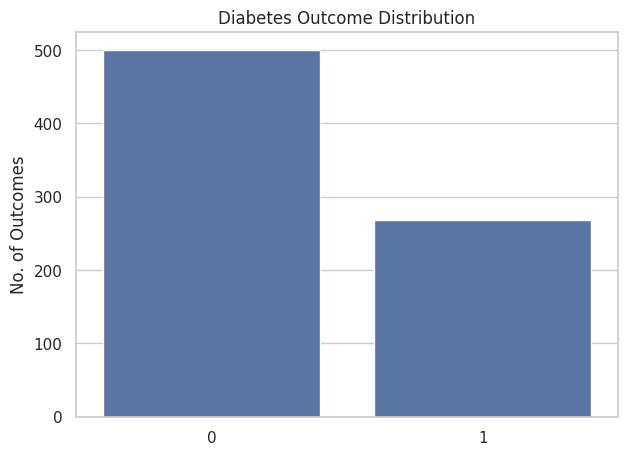

In [17]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Outcome"
)
plt.title("Diabetes Outcome Distribution")
plt.xlabel("")
plt.ylabel("No. of Outcomes")

plt.show()

In [18]:
target_percentage = (
    df["Outcome"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
    )

print(target_percentage)

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


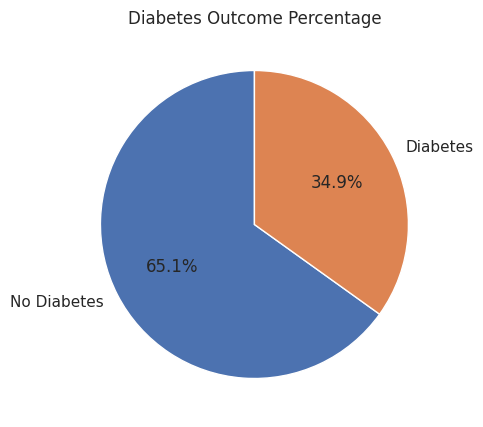

In [20]:
plt.figure(figsize=(7, 5))

plt.pie(
    target_percentage,
    labels=["No Diabetes", "Diabetes"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Diabetes Outcome Percentage")

plt.show()

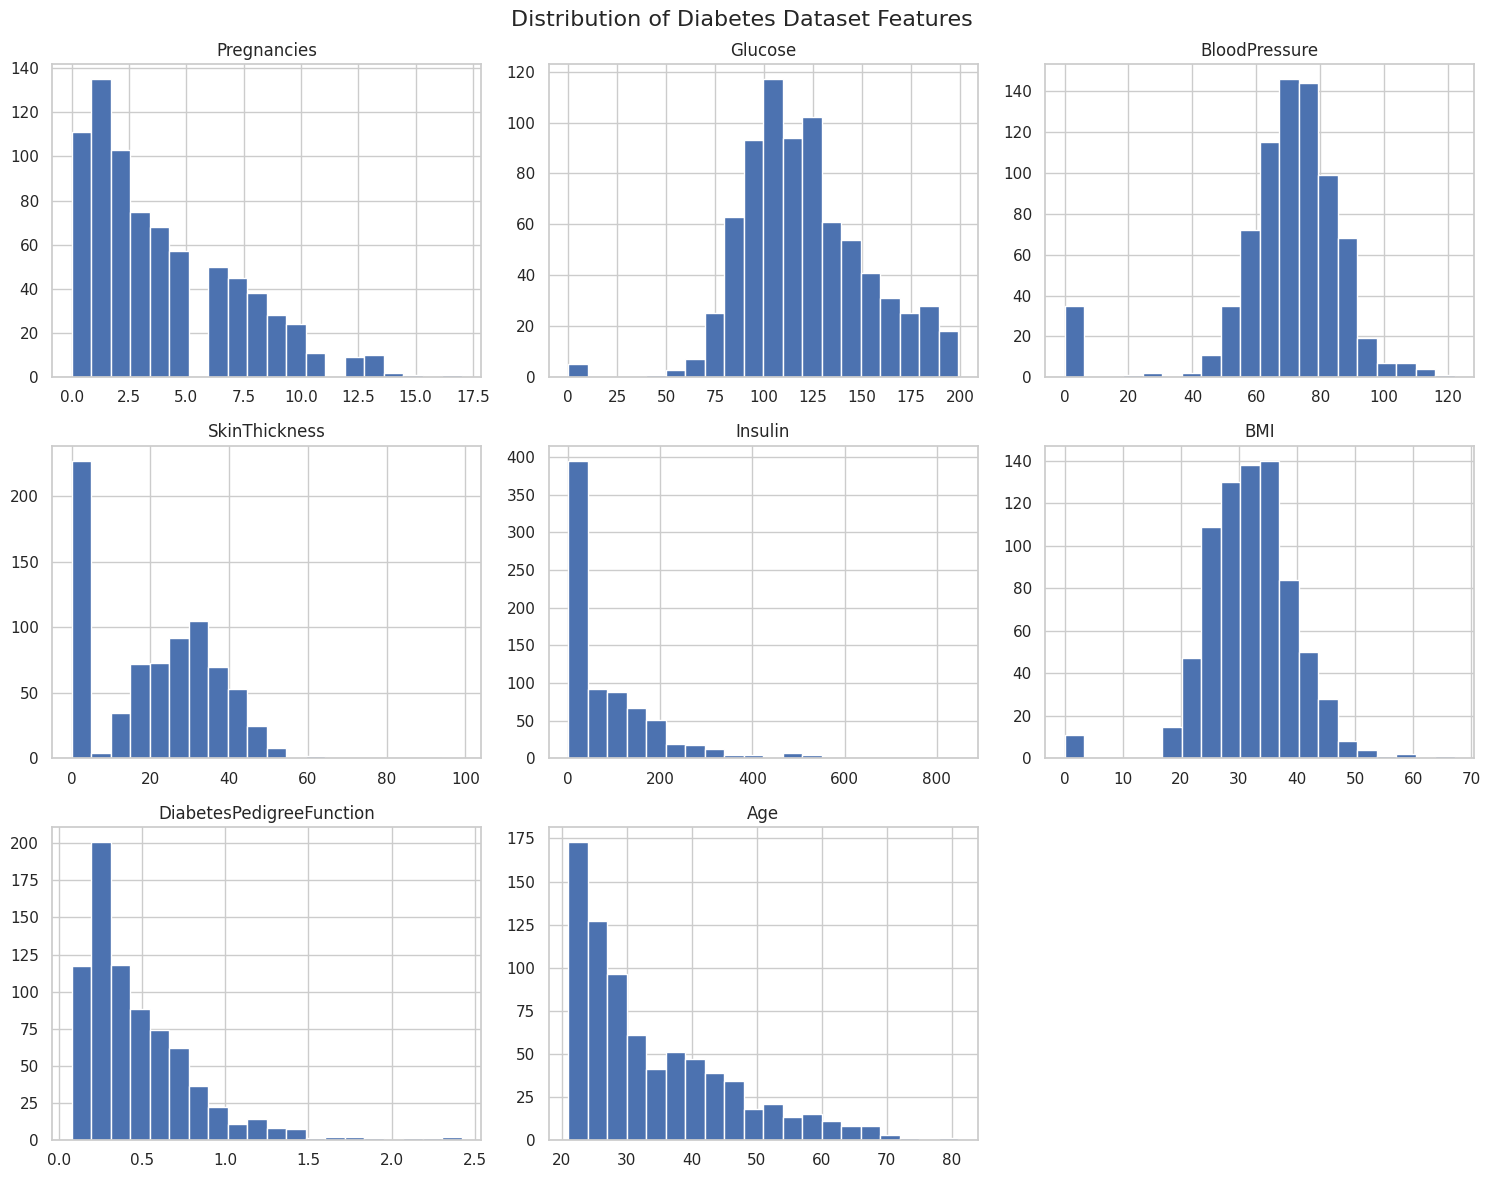

In [19]:
features = df.drop(columns="Outcome").columns

df[features].hist(
    figsize=(15, 12),
    bins=20
)

plt.suptitle(
    "Distribution of Diabetes Dataset Features",
    fontsize=16
)

plt.tight_layout()
plt.show()

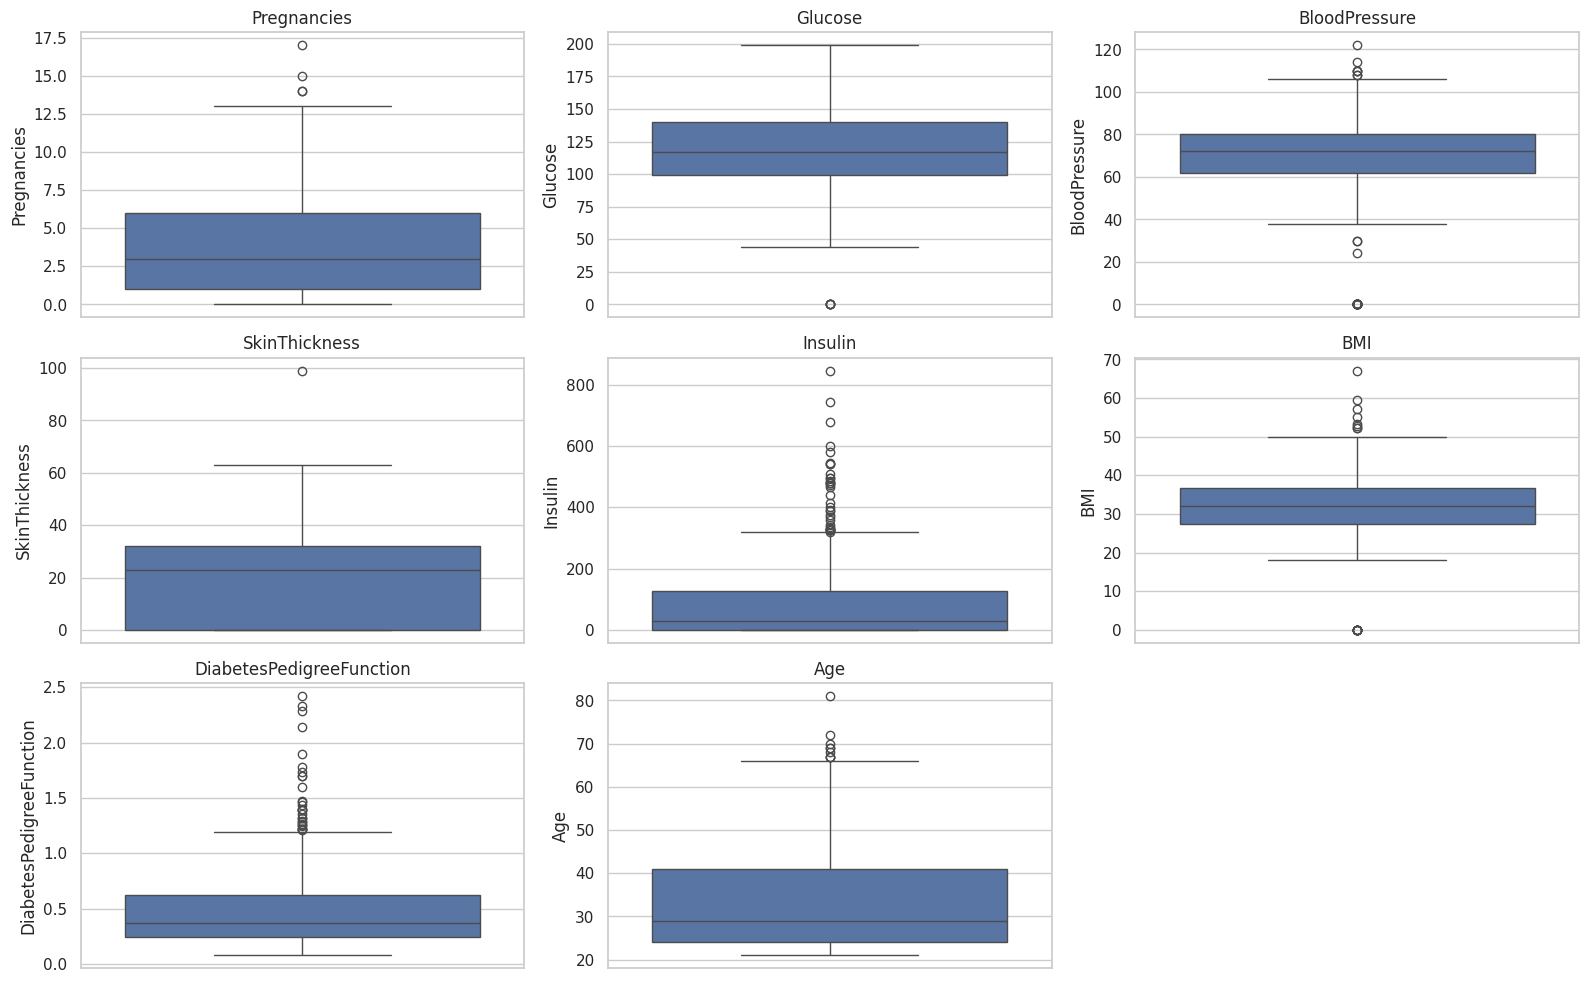

In [21]:
plt.figure(figsize=(16,10))

for i, col in enumerate(features, 1):

  plt.subplot(3, 3, i)

  sns.boxplot(y=df[col])
  plt.title(col)
plt.tight_layout()
plt.show()

In [23]:
zero_columns = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

zero_counts = (df[zero_columns] == 0).sum()

print("Zero Values")
print(zero_counts)

Zero Values
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


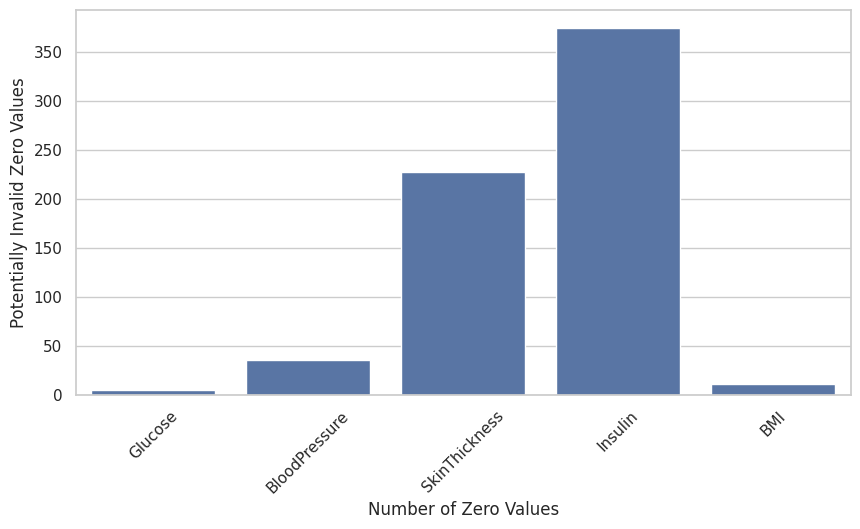

In [24]:
plt.figure(figsize=(10,5))

sns.barplot(x=zero_counts.index, y=zero_counts.values)

plt.xticks(rotation=45)
plt.xlabel("Number of Zero Values")
plt.ylabel("Potentially Invalid Zero Values")

plt.show()

In [25]:
df_clean = df.copy()

df_clean[zero_columns] = df_clean[zero_columns].replace(0,np.nan)

print("Missing values after replacing invalid zeroes:")
print(df_clean.isnull().sum())

Missing values after replacing invalid zeroes:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


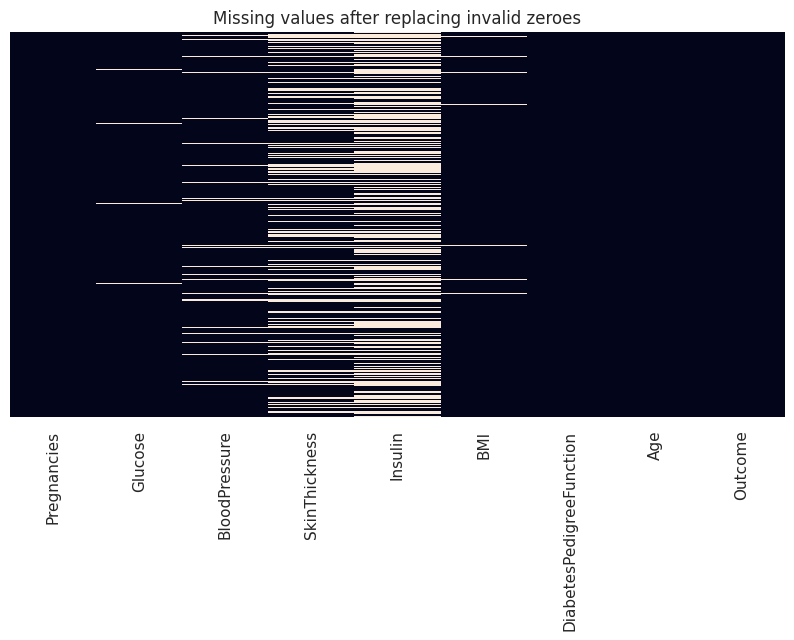

In [26]:
plt.figure(figsize=(10,5))

sns.heatmap(
    df_clean.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing values after replacing invalid zeroes")
plt.show()

In [31]:
for col in zero_columns:

  df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print("Missing values after median imputation:")
print(df_clean.isnull().sum())

Missing values after median imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


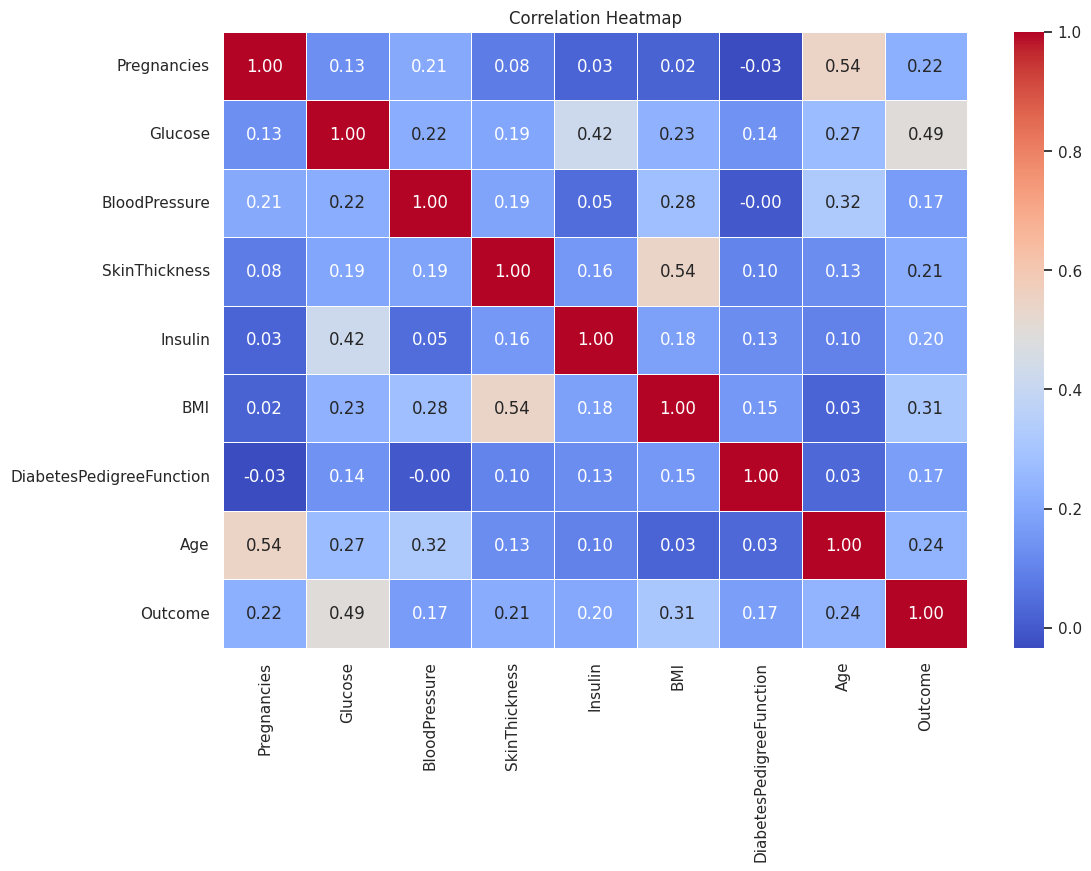

In [32]:
plt.figure(figsize=(12, 8))

correlation = df_clean.corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

In [33]:
target_corr = (df_clean.corr()["Outcome"].drop("Outcome")).sort_values()
print(target_corr)

BloodPressure               0.165723
DiabetesPedigreeFunction    0.173844
Insulin                     0.203790
SkinThickness               0.214873
Pregnancies                 0.221898
Age                         0.238356
BMI                         0.312038
Glucose                     0.492782
Name: Outcome, dtype: float64


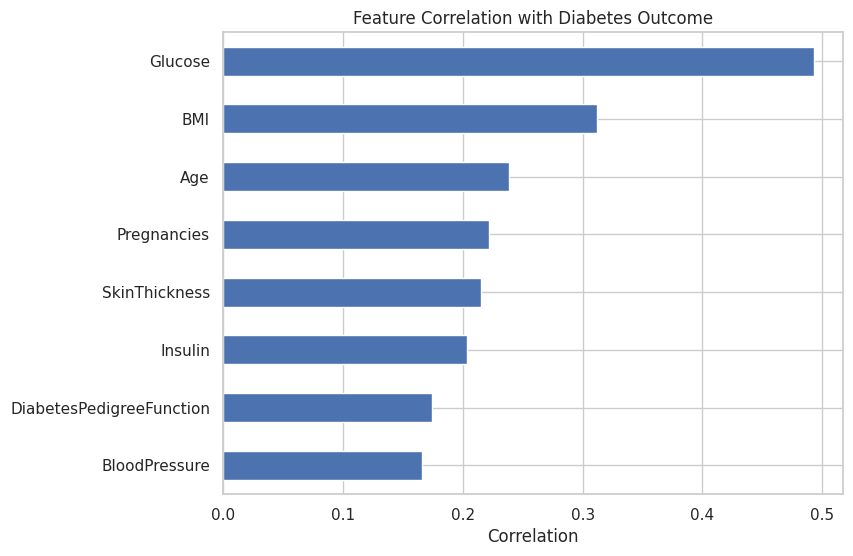

In [34]:
plt.figure(figsize=(8,6))

target_corr.plot(kind="barh")

plt.title("Feature Correlation with Diabetes Outcome")
plt.xlabel("Correlation")

plt.show()

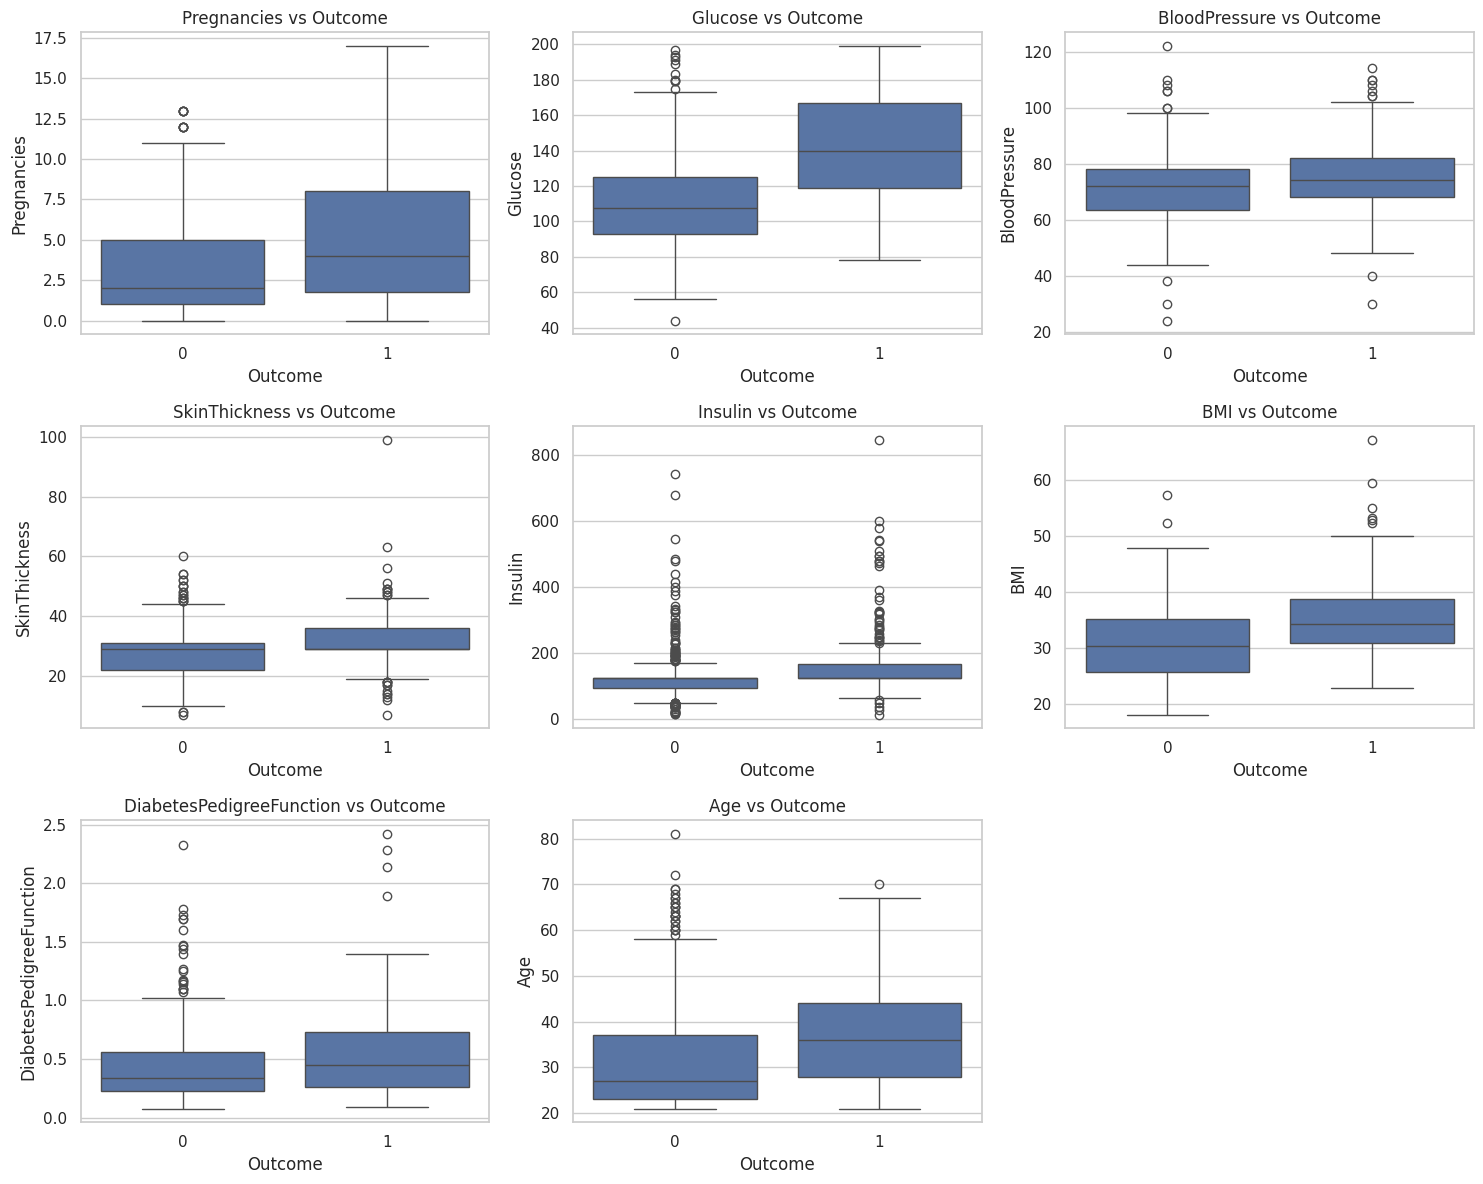

In [35]:
plt.figure(figsize=(15,12))

for i, col in enumerate(features, 1):

  plt.subplot(3, 3, i)

  sns.boxplot(data=df_clean, x="Outcome", y=col)

  plt.title(f"{col} vs Outcome")

plt.tight_layout()
plt.show()

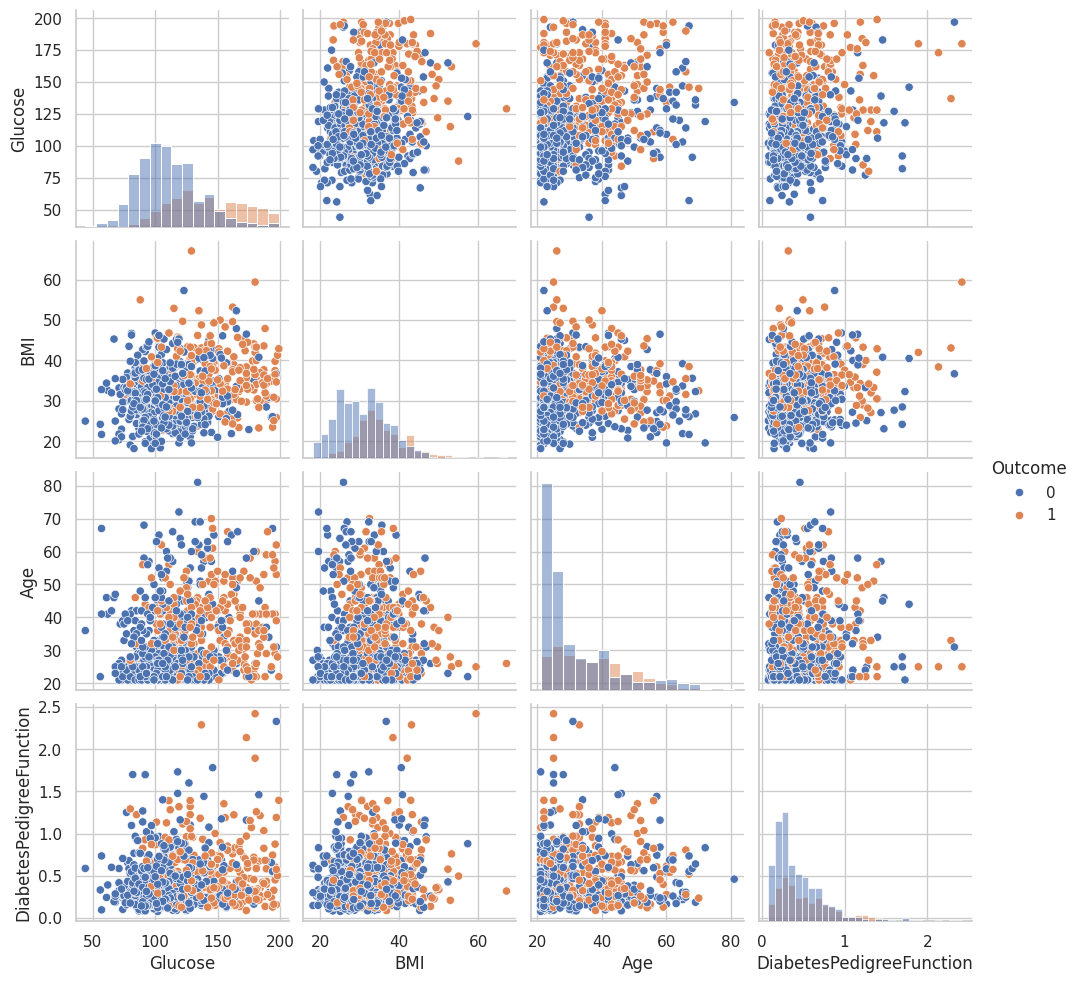

In [36]:
selected_features = ["Glucose", "BMI", "Age", "DiabetesPedigreeFunction","Outcome"]

sns.pairplot(df_clean[selected_features],hue="Outcome", diag_kind="hist")

plt.show()


In [38]:
x = df_clean.drop("Outcome", axis=1)

y = df_clean["Outcome"]

print("X shape:", x.shape)
print("y shape:", y.shape)

X shape: (768, 8)
y shape: (768,)


In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 614
Testing samples: 154


In [48]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaling completed.")

Scaling completed.


In [49]:
scaler.fit_transform(X_test)

array([[ 0.85252995,  1.16484536, -0.8288433 , ..., -0.71933141,
        -0.46562514,  0.63400979],
       [ 1.69054875, -1.66920722,  2.88630463, ...,  0.42561436,
        -0.49253293,  1.24533587],
       [-0.54416805,  0.01253827,  0.23262754, ...,  0.48215489,
         0.09943846, -0.58864236],
       ...,
       [-0.54416805, -1.23319913, -1.89031414, ..., -0.56384494,
         3.73497988, -0.67597466],
       [ 0.01451115,  1.94343123,  0.40953934, ...,  0.63764135,
        -0.55531777, -0.15198088],
       [-0.82350765, -1.57577692,  0.40953934, ...,  0.1005063 ,
        -0.08293657, -1.02530385]])

In [50]:
scaler.transform(X_test)

array([[ 0.85252995,  1.16484536, -0.8288433 , ..., -0.71933141,
        -0.46562514,  0.63400979],
       [ 1.69054875, -1.66920722,  2.88630463, ...,  0.42561436,
        -0.49253293,  1.24533587],
       [-0.54416805,  0.01253827,  0.23262754, ...,  0.48215489,
         0.09943846, -0.58864236],
       ...,
       [-0.54416805, -1.23319913, -1.89031414, ..., -0.56384494,
         3.73497988, -0.67597466],
       [ 0.01451115,  1.94343123,  0.40953934, ...,  0.63764135,
        -0.55531777, -0.15198088],
       [-0.82350765, -1.57577692,  0.40953934, ...,  0.1005063 ,
        -0.08293657, -1.02530385]])

In [54]:
comparison = pd.DataFrame({
    "Original Mean": X_train.mean(),
    "Original Std": X_train.std(),
    "Scaled Mean": X_train_scaled.mean(axis=0),
    "Scaled Std": X_train_scaled.std(axis=0)
})

display(comparison)

,Original Mean,Original Std,Scaled Mean,Scaled Std
Pregnancies,3.819218,3.314148,-6.943414e-17,1.0
Glucose,121.671010,30.003794,-1.099374e-16,1.0
BloodPressure,72.140065,12.275119,3.095606e-16,1.0
SkinThickness,29.042345,8.891855,-3.471707e-17,1.0
Insulin,137.705212,78.764767,-4.339634e-18,1.0
BMI,32.446743,6.824142,-1.148556e-15,1.0
DiabetesPedigreeFunction,0.477428,0.330300,-1.099374e-16,1.0
Age,33.366450,11.833438,-1.084908e-16,1.0


In [58]:
from sklearn.neighbors import KNeighborsClassifier

In [59]:
K = 5

In [60]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)


KNeighborsClassifier()

In [61]:
y_pred = knn.predict(X_test_scaled)

print("Predictions:")
print(y_pred[:20])

Predictions:
[1 0 0 1 0 0 0 1 0 1 0 1 0 0 0 1 1 0 1 0]


In [62]:
y_prob = knn.predict_proba(X_test_scaled)[:, 1]

print(y_prob[:20])

[0.6 0.2 0.2 0.6 0.  0.2 0.2 0.8 0.  0.6 0.4 0.6 0.  0.  0.  0.6 0.8 0.
 1.  0.2]


In [64]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")


Accuracy: 0.7532


In [65]:
precision = precision_score(y_test, y_pred)

print(f"Precision: {precision:.4f}")


Precision: 0.6600


In [66]:
f1 = f1_score(y_test, y_pred)

print(f"F1 Score: {f1:.4f}")

F1 Score: 0.6346
